In [1]:
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import os
import subprocess
import pandas as pd
import numpy as np
import logging
import torch
import scanpy as sc
import anndata
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

In [2]:
adata_rna=sc.read_h5ad("D:\\GP\\Datasets\\bonemarrow_rna.h5ad")
adata_rna

adata_rna.obs.head()

,GEX_n_genes_by_counts,GEX_pct_counts_mt,GEX_size_factors,GEX_phase,ADT_n_antibodies_by_counts,ADT_total_counts,ADT_iso_count,cell_type,batch,ADT_pseudotime_order,...,DonorID,DonorAge,DonorBMI,DonorBloodType,DonorRace,Ethnicity,DonorGender,QCMeds,DonorSmoker,is_train
TCATATCTCGAGAGCA-1-s3d7,1477,5.861183,0.923154,G2M,113,573.0,4.0,CD14+ Mono,s3d7,NaN,...,11466,22,31.5,A+,Asian,NOT HISPANIC OR LATINO,Female,True,Nonsmoker,train
TGCTTGCCAGTGACCC-1-s3d7,1817,5.269367,1.210090,G2M,109,617.0,5.0,CD14+ Mono,s3d7,NaN,...,11466,22,31.5,A+,Asian,NOT HISPANIC OR LATINO,Female,True,Nonsmoker,train
ACTACGAAGCTGGTGA-1-s3d7,1353,11.183650,0.832615,G2M,124,790.0,6.0,CD14+ Mono,s3d7,NaN,...,11466,22,31.5,A+,Asian,NOT HISPANIC OR LATINO,Female,True,Nonsmoker,train
TGTTGGACACTGTGAT-1-s2d1,1281,9.208211,1.036986,G1,95,412.0,3.0,CD14+ Mono,s2d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,iid_holdout
ATGAGTCCATGGCGCT-1-s3d1,557,8.790171,0.740206,G2M,133,1562.0,21.0,CD14+ Mono,s3d1,NaN,...,15078,34,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train


In [3]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [4]:
adata_rna.layers["counts"] = adata_rna.X.copy()

In [5]:
from scimilarity.utils import align_dataset, lognorm_counts
adata_rna = align_dataset(adata_rna, ce.gene_order)
adata_rna = lognorm_counts(adata_rna)

In [6]:
X = adata_rna.layers["counts"]
embeddings = ce.get_embeddings(X)
print(embeddings.shape)

(20000, 128)


In [7]:
print(type(X))
print(X.dtype)

<class 'scipy.sparse._csr.csr_matrix'>
float64


In [8]:
adata_rna.obsm["X_emb"] = embeddings
print(adata_rna.obsm["X_emb"].shape)

(20000, 128)


In [9]:
adata_adt=sc.read_h5ad("D:\\GP\\Datasets\\bonemarrow_adt.h5ad")
adata_adt
adata_adt.layers["counts"] = adata_adt.X.copy()
print(adata_adt.X)

adata_adt.X = adata_adt.layers["counts"].copy()

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 2245975 stored elements and shape (20000, 134)>
  Coords	Values
  (0, 0)	0.6684538125991821
  (1, 0)	0.8865846395492554
  (2, 0)	0.8865846395492554
  (3, 0)	0.3890708088874817
  (4, 0)	1.750258445739746
  (5, 0)	0.8865846395492554
  (6, 0)	0.6684538125991821
  (7, 0)	1.5696303844451904
  (8, 0)	0.3890708088874817
  (9, 0)	0.3890708088874817
  (10, 0)	0.3890708088874817
  (11, 0)	0.3890708088874817
  (12, 0)	1.2172971963882446
  (13, 0)	1.4653973579406738
  (14, 0)	0.6684538125991821
  (15, 0)	1.065550446510315
  (16, 0)	0.6684538125991821
  (18, 0)	1.065550446510315
  (19, 0)	3.575695514678955
  (21, 0)	1.2172971963882446
  (22, 0)	0.3890708088874817
  (24, 0)	0.6684538125991821
  (25, 0)	1.5696303844451904
  (26, 0)	3.0657799243927
  (27, 0)	0.3890708088874817
  :	:
  (19971, 133)	0.19750525057315826
  (19972, 133)	0.36236199736595154
  (19973, 133)	1.0104641914367676
  (19974, 133)	0.6277751326560974
  (19975, 133)	0.10

In [10]:
import sys
!{sys.executable} -m pip install muon


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import muon 
muon.prot.pp.clr(adata_adt)
adata_adt.layers["clr"] = adata_adt.X.copy()

y = adata_adt.layers["clr"]

In [12]:
X_new = adata_rna.obsm["X_emb"]

In [13]:

X_new = X_new.toarray() if hasattr(X_new, "toarray") else X_new
y = y.toarray() if hasattr(y, "toarray") else y


# Model

In [14]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X_new):
    X_train, X_test = X_new[train_idx], X_new[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error

# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.03366328
Per-protein MSE: [0.04602003 0.0288899  0.01686588 0.03352673 0.0237883  0.02814773
 0.02504976 0.02830961 0.01701615 0.02783834 0.03262296 0.06628566
 0.03413571 0.03571416 0.03825587 0.03910657 0.0302678  0.03983116
 0.04058994 0.04599199 0.01951268 0.03145864 0.05623003 0.04311353
 0.03088345 0.0329054  0.0439282  0.04794131 0.0290556  0.01886998
 0.02414944 0.03036346 0.02725724 0.04226337 0.02088446 0.04671288
 0.03887942 0.0314622  0.02629448 0.03902078 0.04372337 0.02586659
 0.04513742 0.05037003 0.06222364 0.03408151 0.01904234 0.02483804
 0.05323341 0.04880534 0.02632589 0.02010088 0.02497165 0.03478209
 0.0533298  0.03561281 0.03982482 0.01571544 0.02041477 0.02323364
 0.04327155 0.03112254 0.03313521 0.02459419 0.02386938 0.04194336
 0.01474459 0.01997969 0.05000571 0.02785164 0.02504182 0.03838075
 0.03664785 0.04154144 0.04746829 0.04359074 0.03581098 0.04702265
 0.02003711 0.02751668 0.02361463 0.02902107 0.02936778 0.04533537
 0.02172359 0.02151514 0.

In [16]:
rmse_per_protein = np.sqrt(mse_per_protein)
avg_rmse = rmse_per_protein.mean()

print("Avg RMSE:", avg_rmse)
print("Per-protein RMSE:", rmse_per_protein)
print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg RMSE: 0.18108706
Per-protein RMSE: [0.2145228  0.16997029 0.12986872 0.18310305 0.15423454 0.16777284
 0.15827115 0.16825461 0.13044597 0.16684826 0.18061826 0.25746003
 0.18475851 0.18898189 0.19559109 0.1977538  0.17397642 0.19957745
 0.20146945 0.21445744 0.13968778 0.17736584 0.23712873 0.20763798
 0.17573686 0.18139845 0.20959055 0.21895504 0.17045704 0.13736807
 0.1554009  0.17425114 0.16509765 0.20558058 0.14451456 0.21613161
 0.19717865 0.17737587 0.16215573 0.1975368  0.20910133 0.16083093
 0.2124557  0.22443269 0.24944666 0.1846118  0.13799396 0.15760088
 0.23072368 0.2209193  0.16225256 0.14177759 0.1580242  0.18649957
 0.23093246 0.18871355 0.19956157 0.12536123 0.14288026 0.15242586
 0.20801814 0.1764158  0.1820308  0.15682535 0.15449718 0.20480077
 0.12142731 0.14134952 0.22361957 0.16688809 0.15824607 0.19591007
 0.19143629 0.20381717 0.2178722  0.20878395 0.18923791 0.21684708
 0.1415525  0.16588151 0.15367052 0.17035572 0.1713703  0.21292104
 0.14738923 0.1466804  

In [17]:
from scipy.stats import pearsonr

pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

print("Avg Pearson correlation:", mean_pearson)
print("Per-protein Pearson correlation:", pearson_per_protein)
print("Per-protein Pearson shape:", pearson_per_protein.shape)

Avg Pearson correlation: 0.6886527
Per-protein Pearson correlation: [0.70767826 0.63402617 0.6996659  0.5662044  0.60168546 0.77598983
 0.8203526  0.67270845 0.6557504  0.82134855 0.86944604 0.7629139
 0.664656   0.83661824 0.8306941  0.8553492  0.8024852  0.8049175
 0.6863562  0.86094195 0.6257344  0.63290817 0.4932345  0.78301877
 0.78974974 0.71574986 0.7612531  0.47647002 0.71608436 0.6525079
 0.65492207 0.755452   0.60851026 0.78646946 0.62907314 0.44175985
 0.68626213 0.8870303  0.59643364 0.8243279  0.6524889  0.65529925
 0.4821695  0.5223786  0.6171446  0.60680175 0.6369529  0.566372
 0.7038575  0.80008453 0.6322829  0.6889544  0.57521117 0.7874528
 0.61875254 0.7793356  0.7066626  0.6718686  0.67406654 0.73678744
 0.8120509  0.5285159  0.6747851  0.7466007  0.71948415 0.71028
 0.70907134 0.7611078  0.72490543 0.8334243  0.6322082  0.7819471
 0.47181457 0.6234253  0.68810207 0.4357528  0.7071926  0.702635
 0.66005665 0.75308233 0.6553844  0.6772797  0.6321556  0.83410954
 0.620

In [18]:
from scipy.stats import spearmanr

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

print("Mean Spearman correlation:", mean_spearman)
print("Per-protein Spearman correlation:", spearman_per_protein)
print("Per-protein Spearman shape:", spearman_per_protein.shape)

Mean Spearman correlation: 0.6444694714103972
Per-protein Spearman correlation: [0.64165058 0.59134995 0.70654474 0.51722221 0.59364176 0.71877366
 0.81171705 0.58093544 0.66829469 0.78412991 0.7819559  0.61265161
 0.58778786 0.6498487  0.72548627 0.74381137 0.78602209 0.78464681
 0.57330611 0.82060819 0.63077929 0.62855466 0.34054243 0.6685539
 0.74630987 0.63912832 0.57889201 0.44253444 0.67395159 0.66244558
 0.65794493 0.66451974 0.58673364 0.78995853 0.64167941 0.449023
 0.64410977 0.83019128 0.56607621 0.78430741 0.580394   0.63179438
 0.49482774 0.45415706 0.60362776 0.58140785 0.65071308 0.56750881
 0.55733148 0.67986913 0.63729609 0.67648953 0.58868772 0.74922845
 0.48054622 0.7090657  0.61436496 0.68906347 0.67857472 0.69159472
 0.77466772 0.42087234 0.62763578 0.72157833 0.73068856 0.68844501
 0.70975272 0.71471828 0.536865   0.8258173  0.5917429  0.71983074
 0.4793001  0.60715157 0.52187324 0.42843262 0.69780282 0.5633017
 0.65980378 0.70139002 0.62596402 0.62210906 0.636145

In [19]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: TCRVd2 (Pearson = 0.3115)
Median: CD29 (Pearson = 0.6885)
Best: CD71 (Pearson = 0.8985)


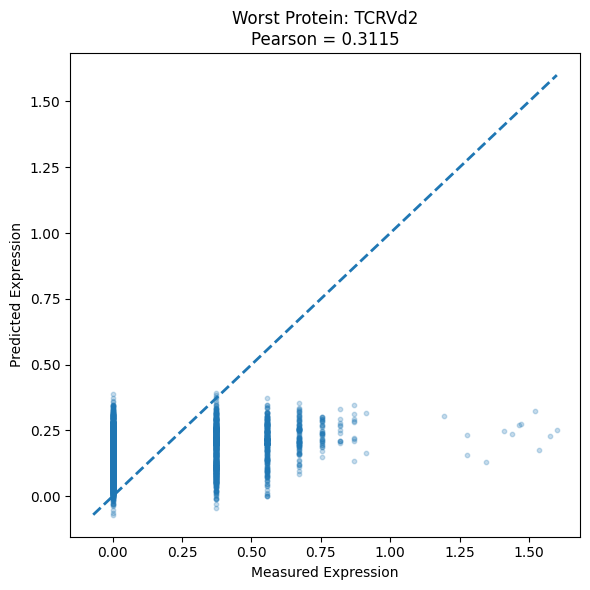

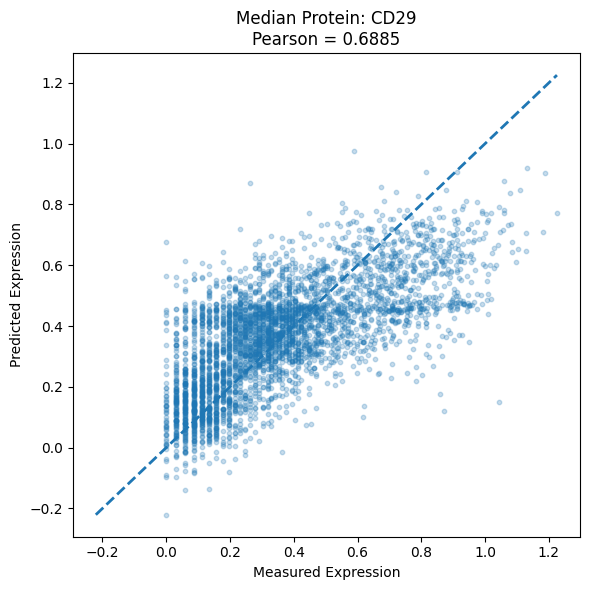

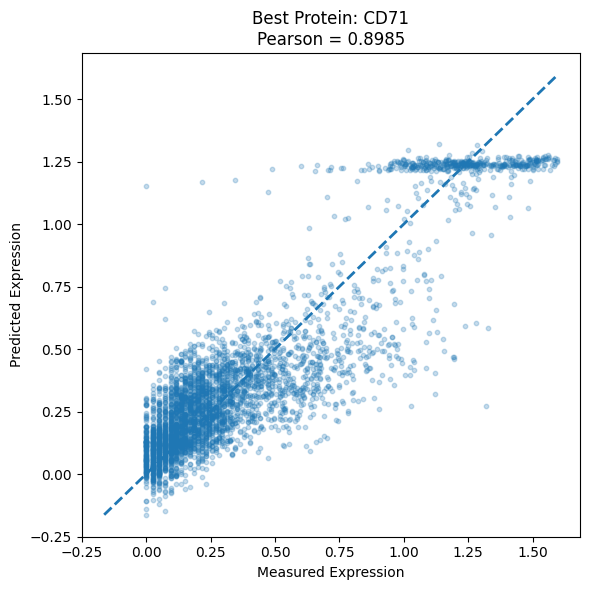

In [20]:
import matplotlib.pyplot as plt
for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [28]:
from pathlib import Path
import numpy as np

save_path = Path("D:/GP/Notebooks/Scimilarity/")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "SCimilarity"  # change per notebook

np.savez(
    save_path / f"{model_name}_bone_marrow_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for SCimilarity at: D:\GP\Notebooks\Scimilarity


## original data no HVG

In [29]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()
mse_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [30]:
import numpy as np
from sklearn.metrics import mean_squared_error

# per-protein MSE
mse_per_protein = ((y_test - y_pred) ** 2).mean(axis=0)

# overall mean
avg_mse = mse_per_protein.mean()

print("Avg MSE:", avg_mse)
print("Per-protein MSE:", mse_per_protein)
print("Per-protein MSE shape:", mse_per_protein.shape)

Avg MSE: 0.0751654655385273
Per-protein MSE: [0.0939117  0.06448624 0.04480349 0.07139439 0.07492992 0.04346519
 0.04520907 0.06636781 0.05063001 0.05905597 0.06047345 0.11654658
 0.07727887 0.07849228 0.0781769  0.082569   0.06166982 0.07814443
 0.0903621  0.08557975 0.05463282 0.05301796 0.11694233 0.09507808
 0.04916442 0.07636007 0.09921556 0.12551011 0.05640477 0.04896328
 0.06137505 0.07003592 0.06066348 0.08457746 0.06473766 0.11907623
 0.05934293 0.06122094 0.05770632 0.07311085 0.08958404 0.07061623
 0.11279322 0.11426676 0.1243247  0.09461627 0.06290361 0.07170934
 0.0977759  0.08737024 0.05963394 0.03886178 0.07401468 0.06595187
 0.1261122  0.08797944 0.09873143 0.04797553 0.05396028 0.06279528
 0.07399896 0.05729425 0.07831449 0.06418314 0.04862397 0.07587345
 0.03867602 0.04647378 0.09410312 0.05728958 0.06139235 0.08388545
 0.08204053 0.0941338  0.10367068 0.10900845 0.07638518 0.10395179
 0.05194427 0.05835519 0.05700942 0.0661109  0.08243976 0.09310486
 0.05929024 0.053

In [31]:
rmse_per_protein = np.sqrt(mse_per_protein)
avg_rmse = rmse_per_protein.mean()

print("Avg RMSE:", avg_rmse)
print("Per-protein RMSE:", rmse_per_protein)
print("Per-protein RMSE shape:", rmse_per_protein.shape)

Avg RMSE: 0.2711735246951713
Per-protein RMSE: [0.30645016 0.25394142 0.21166835 0.26719728 0.27373331 0.20848306
 0.21262425 0.2576195  0.22501114 0.24301434 0.2459135  0.34138918
 0.27799078 0.28016474 0.27960133 0.28734822 0.24833408 0.27954325
 0.3006029  0.29254017 0.23373664 0.23025629 0.34196832 0.30834733
 0.2217305  0.27633326 0.31498502 0.35427405 0.23749687 0.22127647
 0.24773988 0.26464301 0.24629958 0.29082205 0.25443597 0.34507424
 0.24360404 0.24742866 0.2402214  0.27039019 0.29930594 0.26573715
 0.33584701 0.33803366 0.35259708 0.30759758 0.25080592 0.26778599
 0.31269139 0.29558458 0.24420062 0.19713391 0.27205638 0.25681097
 0.3551228  0.29661329 0.31421558 0.21903317 0.23229353 0.25058986
 0.2720275  0.23936217 0.27984726 0.25334392 0.22050843 0.27545135
 0.19666219 0.21557779 0.30676232 0.23935243 0.24777479 0.28962986
 0.28642718 0.30681231 0.32197932 0.33016428 0.27637869 0.32241555
 0.22791286 0.24156818 0.23876645 0.2571204  0.28712324 0.30513089
 0.24349587 0.2

In [32]:
from scipy.stats import pearsonr

pearson_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = pearsonr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    pearson_per_protein.append(corr)

pearson_per_protein = np.array(pearson_per_protein)
mean_pearson = np.nanmean(pearson_per_protein)

print("Avg Pearson correlation:", mean_pearson)
print("Per-protein Pearson correlation:", pearson_per_protein)
print("Per-protein Pearson shape:", pearson_per_protein.shape)

Avg Pearson correlation: 0.5156372756581481
Per-protein Pearson correlation: [0.54739747 0.4585358  0.46549474 0.37107562 0.34844759 0.72696441
 0.73240698 0.48544474 0.39229856 0.69739423 0.78307761 0.66272306
 0.46531851 0.69396951 0.71024261 0.7272575  0.67703235 0.69302437
 0.50012566 0.77312447 0.39383689 0.53986854 0.30321815 0.62130955
 0.72995322 0.53620286 0.58089709 0.22579834 0.58993215 0.42066783
 0.40731765 0.57872307 0.40919354 0.65536044 0.36375502 0.22462712
 0.63641147 0.80349701 0.41736336 0.71817484 0.5037543  0.41885513
 0.26231099 0.32632839 0.46705031 0.37535966 0.36144995 0.30606073
 0.57181093 0.70018076 0.44773033 0.57386315 0.30565187 0.67061398
 0.40060122 0.59037968 0.48715593 0.42414727 0.44836308 0.51427115
 0.73321882 0.43354729 0.47740562 0.52520319 0.58754919 0.5869165
 0.49207491 0.59766139 0.58821732 0.71719644 0.42344058 0.63087084
 0.27904157 0.44326993 0.50218804 0.21147824 0.54894121 0.52354051
 0.44914858 0.60409719 0.46701482 0.47317818 0.419066

In [33]:
from scipy.stats import spearmanr

spearman_per_protein = []

for i in range(y_test.shape[1]):
    if np.std(y_test[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
        corr, _ = spearmanr(y_test[:, i], y_pred[:, i])
    else:
        corr = np.nan
    spearman_per_protein.append(corr)

spearman_per_protein = np.array(spearman_per_protein)
mean_spearman = np.nanmean(spearman_per_protein)

print("Mean Spearman correlation:", mean_spearman)
print("Per-protein Spearman correlation:", spearman_per_protein)
print("Per-protein Spearman shape:", spearman_per_protein.shape)

Mean Spearman correlation: 0.575940608578825
Per-protein Spearman correlation: [0.55336172 0.5644287  0.62527602 0.43928812 0.51970878 0.75858682
 0.79191767 0.49547888 0.57639061 0.7428272  0.72191951 0.57373267
 0.48731193 0.55476367 0.6549016  0.69692209 0.746746   0.75733854
 0.50318821 0.76369154 0.55637857 0.60612424 0.23944102 0.59804937
 0.76754949 0.58270255 0.49676597 0.32633816 0.62627062 0.56799245
 0.54864408 0.57858741 0.51087419 0.72385574 0.52885921 0.33751363
 0.70300033 0.77671918 0.49265615 0.7107271  0.57034355 0.53632377
 0.36402683 0.37434669 0.53999531 0.51374695 0.55355717 0.47627358
 0.51256016 0.63097732 0.60643293 0.64389951 0.486207   0.67807862
 0.36917262 0.62411121 0.51830695 0.61060481 0.58283291 0.62362091
 0.73492304 0.49062701 0.57052377 0.63075472 0.68279234 0.60572853
 0.62322319 0.66077848 0.47647531 0.77412706 0.49422859 0.64190472
 0.39532124 0.56074466 0.42172244 0.32866397 0.6451037  0.50279814
 0.59904948 0.65244426 0.56890781 0.54671907 0.553

In [34]:
valid_idx = np.where(~np.isnan(pearson_per_protein))[0]
valid_scores = pearson_per_protein[valid_idx]

sorted_idx = valid_idx[np.argsort(valid_scores)]

worst_idx = sorted_idx[0]
median_idx = sorted_idx[len(sorted_idx)//2]
best_idx = sorted_idx[-1]

selected_idx = [worst_idx, median_idx, best_idx]
labels = ["Worst", "Median", "Best"]

protein_names = np.array(adata_adt.var_names)

print("\nSelected proteins:")
for label, idx in zip(labels, selected_idx):
    print(
        f"{label}: {protein_names[idx]} "
        f"(Pearson = {pearson_per_protein[idx]:.4f})"
    )


Selected proteins:
Worst: TCRVd2 (Pearson = 0.1502)
Median: CD73 (Pearson = 0.5102)
Best: CD5 (Pearson = 0.8035)


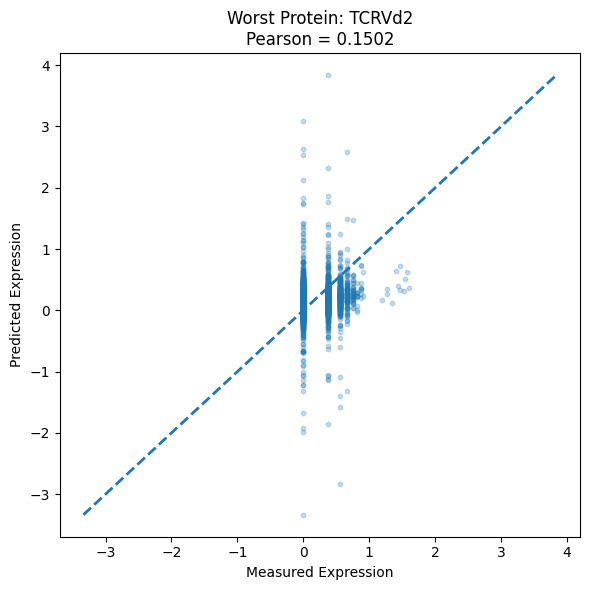

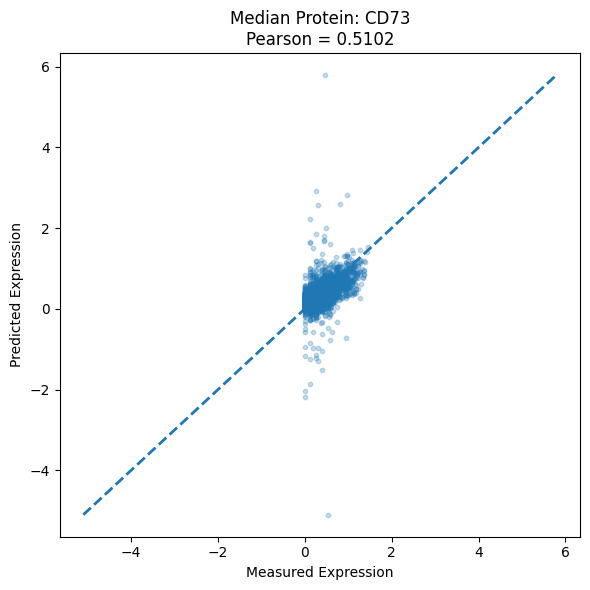

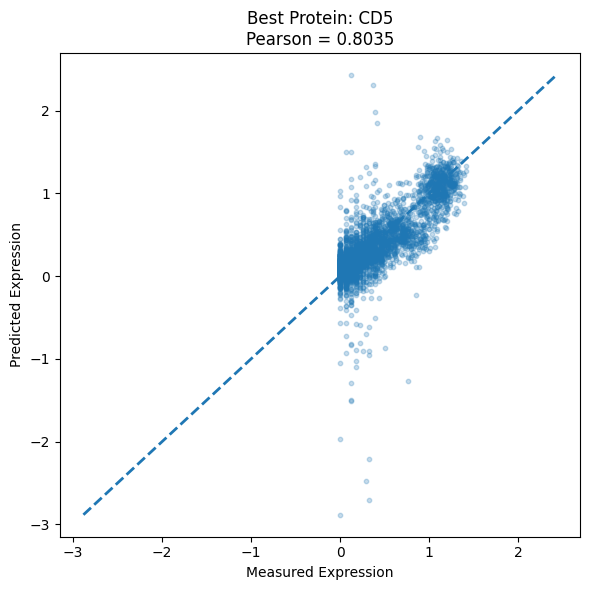

In [35]:
import matplotlib.pyplot as plt
for label, idx in zip(labels, selected_idx):

    x = y_test[:, idx]
    yhat = y_pred[:, idx]

    plt.figure(figsize=(6,6))

    plt.scatter(
        x,
        yhat,
        s=10,
        alpha=0.25
    )

    mn = min(x.min(), yhat.min())
    mx = max(x.max(), yhat.max())

    plt.plot([mn, mx], [mn, mx], "--", linewidth=2)

    plt.xlabel("Measured Expression")
    plt.ylabel("Predicted Expression")

    plt.title(
        f"{label} Protein: {protein_names[idx]}\n"
        f"Pearson = {pearson_per_protein[idx]:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [36]:
from pathlib import Path
import numpy as np

save_path = Path("D:/GP/Notebooks/Scimilarity/")
save_path.mkdir(parents=True, exist_ok=True)

model_name = "Original"  # change per notebook

np.savez(
    save_path / f"{model_name}_Bone_marrow_noHVG_protein_results.npz", # change dataset name

    # raw outputs
    y_test=y_test,
    y_pred=y_pred,

    # metadata
    protein_names=protein_names,

    # metrics
    pearson_per_protein=pearson_per_protein,

    # selected indices (diagnostic)
    worst_idx=worst_idx,
    median_idx=median_idx,
    best_idx=best_idx,

    selected_idx=np.array(selected_idx),

    mean_pearson=np.nanmean(pearson_per_protein),
)

print(f"Saved results for {model_name} at:", save_path)

Saved results for Original at: D:\GP\Notebooks\Scimilarity
